In [1]:
print("Hello Macro Notebook")
a = ("I am awesome. I am strong. I am happy. I am calm.")
print(a)

Hello Macro Notebook
I am awesome. I am strong. I am happy. I am calm.


#Data dictionary 数据口径
1. CPI: https://fred.stlouisfed.org/series/CPILFESL\
Units: Index 1982-1984=100  
The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy" is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy. This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices. The Bureau of Labor Statistics defines and measures the official CPI.
Seasonally Adjusted
2. FFR: https://fred.stlouisfed.org/series/FEDFUNDS\
Units: Percent,
The federal funds rate is the interest rate at which depository institutions trade federal funds (balances held at Federal Reserve Banks) with each other overnight. 
Not Seasonally Adjusted
3. GDP: https://fred.stlouisfed.org/series/GDP\
Units: Billions of Dollars,
Gross domestic product (GDP), the featured measure of U.S. output, is the market value of the goods and services produced by labor and property located in the United States.
Seasonally Adjusted Annual Rate
4. MCUMFN: Capacity Utilization: Manufacturing (NAICS)\
https://fred.stlouisfed.org/series/MCUMFN  
Percent of Capacity
For a given industry, the capacity utilization rate is equal to an output index divided by a capacity index. The Federal Reserve Board's capacity indexes attempt to capture the concept of sustainable maximum output-the greatest level of output a plant can maintain within the framework of a realistic work schedule, after factoring in normal downtime and assuming sufficient availability of inputs to operate the capital in place.
Seasonally Adjusted  
5. T10Y3MM: 10-Year Treasury Constant Maturity Minus 3-Month Treasury Constant Maturity\
https://fred.stlouisfed.org/series/T10Y3MM  
Percent
Series is calculated as the spread between 10-Year Treasury Constant Maturity (BC_10YEARM) and 3-Month Treasury Constant Maturity (BC_3MONTHM).


6. PERMIT: New Privately-Owned Housing Units Authorized in Permit-Issuing Places: Total Units (PERMIT)  
https://fred.stlouisfed.org/series/PERMIT
Thousands of Units
Starting with the 2005-02-16 release, the series reflects an increase in the universe of permit-issuing places

7. S&P500
https://fred.stlouisfed.org/series/SP500

8. Credit spread - BAMLH0A0HYM2: ICE BofA US High Yield Index Option-Adjusted Spread 
https://fred.stlouisfed.org/series/BAMLH0A0HYM2
A credit spread is the difference in yield between two debt securities with the same maturity but different credit quality. It's also known as a yield spread. 

9. Credit spread - BAA10Y: Moody's Seasoned Baa Corporate Bond Yield Relative to Yield on 10-Year Treasury Constant Maturity
https://fred.stlouisfed.org/series/BAA10Y

10. Corporate profits After Tax (without IVA and CCAdj) (CP)
 Profit per unit of real gross value added of nonfinancial corporate business: Corporate profits after tax with IVA and CCAdj (unit profits from current production) (A466RD3Q052SBEA)
 https://fred.stlouisfed.org/series/A466RD3Q052SBEA

11. wage
https://fred.stlouisfed.org/series/LES1252881600Q

12. Market volatility (fear) - VIX
https://fred.stlouisfed.org/series/VIXCLS
A popular measure of the implied volatility of the S&P's 500 index, a commonly cited gauge of market fear. A measure of market's expectations for stock market volatility over the next 30 days. 

13. Business leverage cycle 
Chicago Fed National Financial Conditions Index Nonfinancial Leveral Subindex (NFCINONFINLEVERAGE)
https://fred.stlouisfed.org/series/NFCINONFINLEVERAGE

14. *** (important) St Louis financial stress index 
 https://fred.stlouisfed.org/series/STLFSI4

15. Share of Labour Compensation in GDP at Current National Prices for United States (LABSHPUSA156NRUG)	
https://fred.stlouisfed.org/series/LABSHPUSA156NRUG
Nonfarm Business Sector: Labor Share for All Workers (PRS85006171)
https://fred.stlouisfed.org/series/PRS85006171

16. US Unemployment Rate (UNRATE)
https://fred.stlouisfed.org/series/UNRATE

17. Real interest rate (10yr)
https://fred.stlouisfed.org/series/REAINTRATREARAT10Y

18. GDP (governs business sales growth and household income growth, ultimately cash flows throughout economy)
https://fred.stlouisfed.org/series/GDP

19. M2 
https://fred.stlouisfed.org/series/M2SL

20. S&P500 PE ratio 

21. Federal bank balance sheet: 
https://fred.stlouisfed.org/series/WALCL

In [25]:
# Bard帮我优化code
#下载数据，存到csv，初步打印检查一下
import requests
import pandas as pd
from datetime import date

# Define the URLs
urls = [
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=718&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=CPILFENS&scale=left&cosd=1957-01-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-21&revision_date=2023-11-21&nd=1957-01-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1138&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=FEDFUNDS&scale=left&cosd=1954-07-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-21&revision_date=2023-11-21&nd=1954-07-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1318&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=GDP&scale=left&cosd=1947-01-01&coed=2023-07-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Quarterly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-21&revision_date=2023-11-21&nd=1947-01-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1138&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=MCUMFN&scale=left&cosd=1972-01-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-22&revision_date=2023-11-22&nd=1972-01-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1138&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=T10Y3MM&scale=left&cosd=1982-01-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-22&revision_date=2023-11-22&nd=1982-01-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1138&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=PERMIT&scale=left&cosd=1960-01-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-22&revision_date=2023-11-22&nd=1960-01-01",
    "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1138&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=SP500&scale=left&cosd=2013-12-01&coed=2023-10-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-11-22&revision_date=2023-11-22&nd=2013-11-22"
]

# Get today's date
today = date.today().strftime("%Y-%m")

# Define the filenames with today's date
filenames = [f"CPILFESL_{today}.csv", 
             f"FEDFUNDS_{today}.csv",
             f"GDP_{today}.csv",
             f"MCUMFN_{today}.csv",
             f"T10Y3MM_{today}.csv",
             f"PERMIT_{today}.csv",
             f"SP500_{today}.csv"]


# Loop through the URLs and filenames
for url, filename in zip(urls, filenames):
    # Download data from the URL
    response = requests.get(url)

    # Check if the response was successful
    if response.status_code == 200:
        # Save the downloaded data to the filename
        with open(filename, "wb") as f:
            f.write(response.content)

        # Read the CSV data into a pandas DataFrame
        data = pd.read_csv(filename)
        print(data)
    else:
        print(f"Error downloading data from {url}")


           DATE  CPILFENS
0    1957-01-01    28.500
1    1957-02-01    28.500
2    1957-03-01    28.700
3    1957-04-01    28.800
4    1957-05-01    28.800
..          ...       ...
797  2023-06-01   308.910
798  2023-07-01   309.402
799  2023-08-01   310.103
800  2023-09-01   310.817
801  2023-10-01   311.380

[802 rows x 2 columns]
           DATE  FEDFUNDS
0    1954-07-01      0.80
1    1954-08-01      1.22
2    1954-09-01      1.07
3    1954-10-01      0.85
4    1954-11-01      0.83
..          ...       ...
827  2023-06-01      5.08
828  2023-07-01      5.12
829  2023-08-01      5.33
830  2023-09-01      5.33
831  2023-10-01      5.33

[832 rows x 2 columns]
           DATE        GDP
0    1947-01-01    243.164
1    1947-04-01    245.968
2    1947-07-01    249.585
3    1947-10-01    259.745
4    1948-01-01    265.742
..          ...        ...
302  2022-07-01  25994.639
303  2022-10-01  26408.405
304  2023-01-01  26813.601
305  2023-04-01  27063.012
306  2023-07-01  27623.543

[30

In [28]:
#形成时间序列的dataframe

import pandas as pd

# Load the CSV data into pandas DataFrames
# Get today's date
today = date.today().strftime("%Y-%m")

df_cpilfens = pd.read_csv(f"CPILFESL_{today}.csv")
df_fedfunds = pd.read_csv(f"FEDFUNDS_{today}.csv")
df_gdp = pd.read_csv(f"GDP_{today}.csv")

# Merge the two DataFrames based on the 'DATE' column
merged_df = df_cpilfens.merge(df_fedfunds, on='DATE', how='left')
merged_df = merged_df.merge(df_gdp, on='DATE', how='left')

# Rename the columns for clarity
merged_df.columns = ['DATE', 'CPILFENS', 'FEDFUNDS' , 'GDP']

# Print the time series DataFrame
print(merged_df)

           DATE  CPILFENS  FEDFUNDS        GDP
0    1957-01-01    28.500      2.84    469.779
1    1957-02-01    28.500      3.00        NaN
2    1957-03-01    28.700      2.96        NaN
3    1957-04-01    28.800      3.00    472.025
4    1957-05-01    28.800      3.00        NaN
..          ...       ...       ...        ...
797  2023-06-01   308.910      5.08        NaN
798  2023-07-01   309.402      5.12  27623.543
799  2023-08-01   310.103      5.33        NaN
800  2023-09-01   310.817      5.33        NaN
801  2023-10-01   311.380      5.33        NaN

[802 rows x 4 columns]


In [31]:
#另一种批量方法生产时间序列dataframe
from functools import reduce
print(filenames)

# Read each CSV file into a DataFrame and store them in a list
dfs = [pd.read_csv(file) for file in filenames]

# Define the key column for the left join (assuming 'timestamp' is the common column)
key_column = 'DATE'

# Perform the left join using the reduce function
# This combines the DataFrames in the list based on the key_column
m_df = reduce(lambda left, right: pd.merge(left, right, on=key_column, how='left'), dfs)

# Display the merged DataFrame
print(m_df)

['CPILFESL_2023-11.csv', 'FEDFUNDS_2023-11.csv', 'GDP_2023-11.csv', 'MCUMFN_2023-11.csv', 'T10Y3MM_2023-11.csv', 'PERMIT_2023-11.csv', 'SP500_2023-11.csv']
           DATE  CPILFENS  FEDFUNDS        GDP   MCUMFN  T10Y3MM  PERMIT  \
0    1957-01-01    28.500      2.84    469.779      NaN      NaN     NaN   
1    1957-02-01    28.500      3.00        NaN      NaN      NaN     NaN   
2    1957-03-01    28.700      2.96        NaN      NaN      NaN     NaN   
3    1957-04-01    28.800      3.00    472.025      NaN      NaN     NaN   
4    1957-05-01    28.800      3.00        NaN      NaN      NaN     NaN   
..          ...       ...       ...        ...      ...      ...     ...   
797  2023-06-01   308.910      5.08        NaN  77.5839    -1.67  1441.0   
798  2023-07-01   309.402      5.12  27623.543  77.7662    -1.59  1443.0   
799  2023-08-01   310.103      5.33        NaN  77.7145    -1.39  1541.0   
800  2023-09-01   310.817      5.33        NaN  77.7679    -1.18  1471.0   
801  202

In [33]:
# 计算YoY的inflation & MoM inflation，看下pandas time series

merged_df['inflation_yoy'] = (
    (merged_df['CPILFENS']- merged_df['CPILFENS'].shift(12)) / merged_df['CPILFENS'])

merged_df['inflation_mom'] = (
    (merged_df['CPILFENS']- merged_df['CPILFENS'].shift(1)) / merged_df['CPILFENS'])

merged_df['gdp_yoy'] = (
    (merged_df['GDP']- merged_df['GDP'].shift(12)) / merged_df['GDP'])

print(merged_df)


           DATE  CPILFENS  FEDFUNDS        GDP  inflation_yoy  inflation_mom  \
0    1957-01-01    28.500      2.84    469.779            NaN            NaN   
1    1957-02-01    28.500      3.00        NaN            NaN       0.000000   
2    1957-03-01    28.700      2.96        NaN            NaN       0.006969   
3    1957-04-01    28.800      3.00    472.025            NaN       0.003472   
4    1957-05-01    28.800      3.00        NaN            NaN       0.000000   
..          ...       ...       ...        ...            ...            ...   
797  2023-06-01   308.910      5.08        NaN       0.046065       0.002635   
798  2023-07-01   309.402      5.12  27623.543       0.044460       0.001590   
799  2023-08-01   310.103      5.33        NaN       0.041680       0.002261   
800  2023-09-01   310.817      5.33        NaN       0.039814       0.002297   
801  2023-10-01   311.380      5.33        NaN       0.038747       0.001808   

      gdp_yoy  
0         NaN  
1      

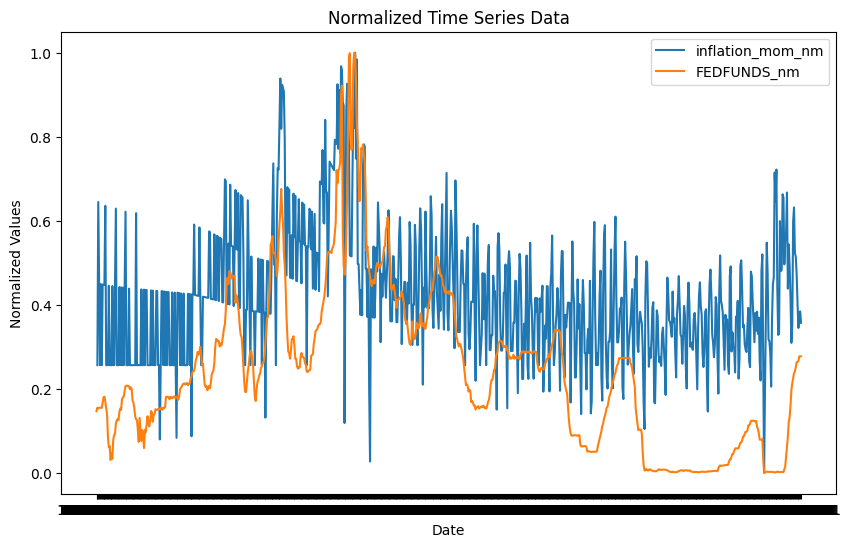

In [34]:
# 初步作图，看下correlation，trends normalize to 100 之后 overlay each other
# 任意 2-3个变量画在一起作图怎么看（单位不同的情况下）

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# TRY normalize certain variables 
scaler = MinMaxScaler()
merged_df[['inflation_mom_nm', 'FEDFUNDS_nm']] = \
    scaler.fit_transform(merged_df[['inflation_mom', 'FEDFUNDS']])

# Plot the normalized time series data
plt.figure(figsize=(10, 6))
plt.plot(merged_df['DATE'], merged_df['inflation_mom_nm'], label='inflation_mom_nm')
plt.plot(merged_df['DATE'], merged_df['FEDFUNDS_nm'], label='FEDFUNDS_nm')
plt.xlabel('Date')
plt.ylabel('Normalized Values')
plt.title('Normalized Time Series Data')
plt.legend()
plt.show()


In [59]:
print(merged_df.dtypes)
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])
print(merged_df.dtypes)
print(merged_df)

DATE                datetime64[ns]
CPILFENS                   float64
FEDFUNDS                   float64
GDP                        float64
inflation_yoy              float64
inflation_mom              float64
gdp_yoy                    float64
inflation_mom_nm           float64
FEDFUNDS_nm                float64
dtype: object
DATE                datetime64[ns]
CPILFENS                   float64
FEDFUNDS                   float64
GDP                        float64
inflation_yoy              float64
inflation_mom              float64
gdp_yoy                    float64
inflation_mom_nm           float64
FEDFUNDS_nm                float64
dtype: object
          DATE  CPILFENS  FEDFUNDS        GDP  inflation_yoy  inflation_mom  \
0   1957-01-01    28.500      2.84    469.779            NaN            NaN   
1   1957-02-01    28.500      3.00        NaN            NaN       0.000000   
2   1957-03-01    28.700      2.96        NaN            NaN       0.006969   
3   1957-04-01    28.800  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


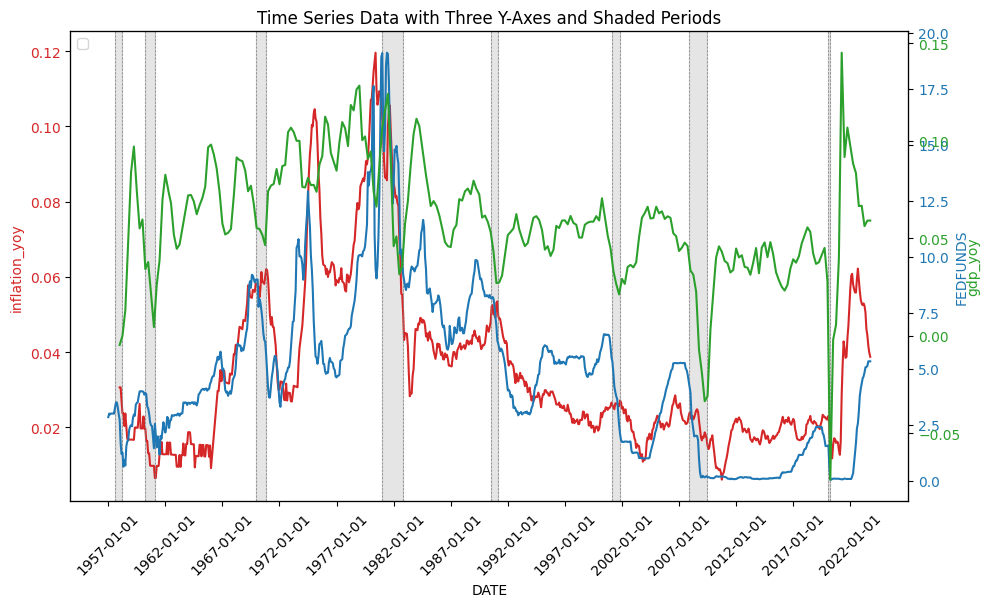

In [78]:
# show two different y-axes for two different variables with different scales 
# on the same chart

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('DATE')
ax1.set_ylabel('inflation_yoy', color=color)
ax1.plot(merged_df['DATE'], merged_df['inflation_yoy'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('FEDFUNDS', color=color)
ax2.plot(merged_df['DATE'], merged_df['FEDFUNDS'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

#Remove NaN values: You can drop rows with NaN values before plotting. 
#This can be done using the dropna() method.
#merged_df.dropna(subset=['gdp_yoy'], inplace=True)
#If you need to keep the original DataFrame and create a new one without modifying the original
# you can do the following:
#cleaned_df = merged_df.dropna(subset=['gdp_yoy'])

#Interpolate NaN values: Another option is to interpolate the missing values. 
# This can be useful if you want to maintain the temporal structure of the data.
merged_df['gdp_yoy'].interpolate(inplace=True)
# Plot the third variable on the same scale as the second variable
ax3 = ax1.twinx()
color3 = 'tab:green'
ax3.set_ylabel('gdp_yoy', color=color3)
ax3.plot(merged_df['DATE'], merged_df['gdp_yoy'], color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Add vertical lines and color areas between lines
# Define the periods you want to grey out (adjust these dates based on your data)
periods = [
    ('1957-08-01', '1958-04-01'),
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01','1970-11-01'),
    ('1981-01-01','1982-11-01'),
    ('1990-07-01','1991-03-01'),
    ('2001-03-01','2001-11-01'),
    ('2007-12-01','2009-06-01'),
    ('2020-02-01','2020-04-01')
]

for start, end in periods:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    # Add vertical lines
    ax1.axvline(x=start, color='grey', linestyle='--', linewidth=0.5)
    ax1.axvline(x=end, color='grey', linestyle='--', linewidth=0.5)

    # Add colored areas between lines
    ax1.axvspan(start, end, alpha=0.2, color='grey')

# Set x-axis ticks and labels
n = 60  # Display every 60th label
ax1.set_xticks(merged_df['DATE'][::n])
ax1.set_xticklabels(merged_df['DATE'].dt.strftime('%Y-%m-%d')[::n], rotation=45)


# Adjust the layout to prevent overlapping labels
fig.tight_layout()
# Display the legend
ax1.legend(loc='upper left')
plt.title('Time Series Data with Three Y-Axes and Shaded Periods')
plt.show()

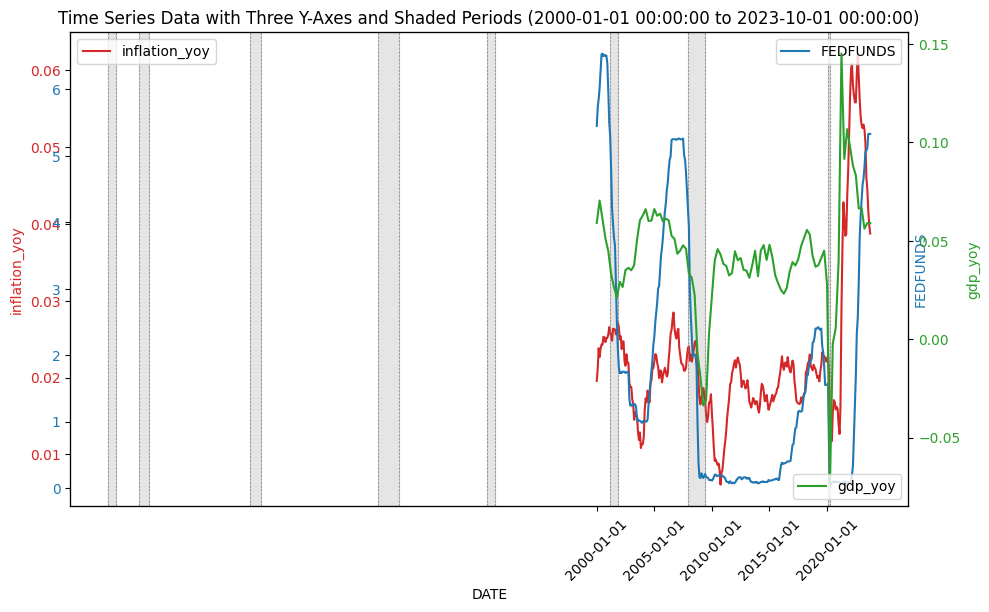

In [86]:
i

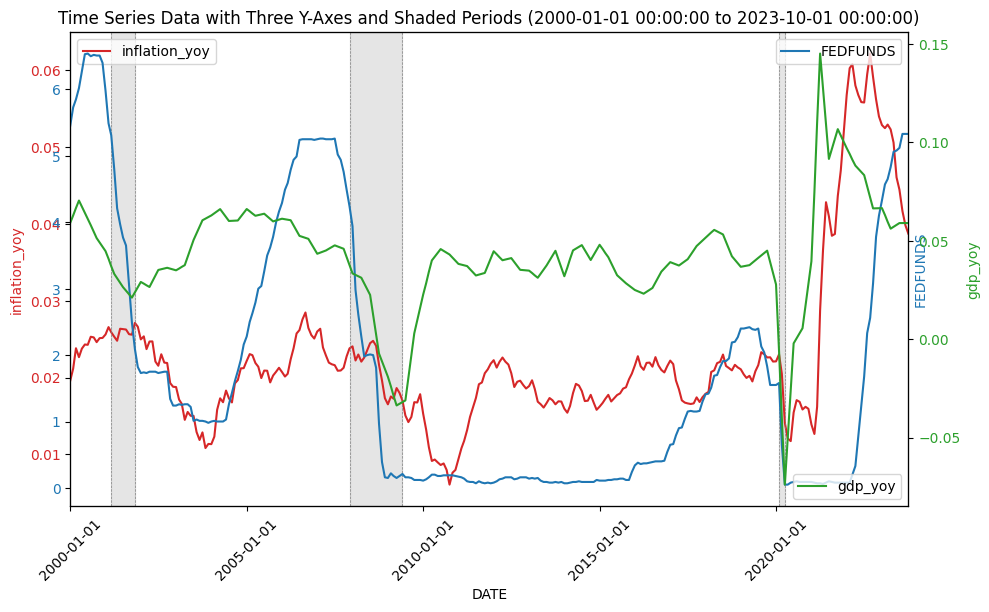

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'merged_df' is your DataFrame
# Convert 'DATE' column to datetime type (if not already)
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

# Get user input for start and end dates
start_date_input = input("Enter start date (YYYY-MM-DD) or press Enter for all dates: ")
end_date_input = input("Enter end date (YYYY-MM-DD) or press Enter for all dates: ")

# Default to all dates if no input provided
if not start_date_input:
    start_date = merged_df['DATE'].min()
else:
    start_date = pd.to_datetime(start_date_input)

if not end_date_input:
    end_date = merged_df['DATE'].max()
else:
    end_date = pd.to_datetime(end_date_input)

# Filter DataFrame based on user input
subset_df = merged_df[(merged_df['DATE'] >= start_date) & (merged_df['DATE'] <= end_date)]

# Plot the subset of data
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first variable on the left y-axis
color1 = 'tab:red'
ax1.set_xlabel('DATE')
ax1.set_ylabel('inflation_yoy', color=color1)
ax1.plot(subset_df['DATE'], subset_df['inflation_yoy'], color=color1, label='inflation_yoy')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis (right y-axis) for the second variable
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('FEDFUNDS', color=color2)
ax2.plot(subset_df['DATE'], subset_df['FEDFUNDS'], color=color2, label='FEDFUNDS')
ax2.tick_params(axis='y', labelcolor=color2)

# Plot the third variable on the same scale as the second variable
ax3 = ax2.twinx()
color3 = 'tab:green'
ax3.set_ylabel('gdp_yoy', color=color3)
ax3.plot(subset_df['DATE'], subset_df['gdp_yoy'], color=color3, label='gdp_yoy')
ax3.tick_params(axis='y', labelcolor=color3)

# Add vertical lines and color areas between lines
# Define the periods you want to grey out (adjust these dates based on your data)
periods = [
    ('1957-08-01', '1958-04-01'),
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01','1970-11-01'),
    ('1981-01-01','1982-11-01'),
    ('1990-07-01','1991-03-01'),
    ('2001-03-01','2001-11-01'),
    ('2007-12-01','2009-06-01'),
    ('2020-02-01','2020-04-01')
]

for start, end in periods:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    # Add vertical lines
    ax1.axvline(x=start, color='grey', linestyle='--', linewidth=0.5)
    ax1.axvline(x=end, color='grey', linestyle='--', linewidth=0.5)

    # Add colored areas between lines
    ax1.axvspan(start, end, alpha=0.2, color='grey')

# Set x-axis limits
ax1.set_xlim(start_date, end_date)

# Set x-axis ticks and labels
n = 60  # Display every 60th label
ax1.set_xticks(subset_df['DATE'][::n])
ax1.set_xticklabels(subset_df['DATE'].dt.strftime('%Y-%m-%d')[::n], rotation=45)

# Display the legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='lower right')

# Adjust the layout to prevent overlapping labels
fig.tight_layout()

plt.title(f'Time Series Data with Three Y-Axes and Shaded Periods ({start_date} to {end_date})')
plt.show()


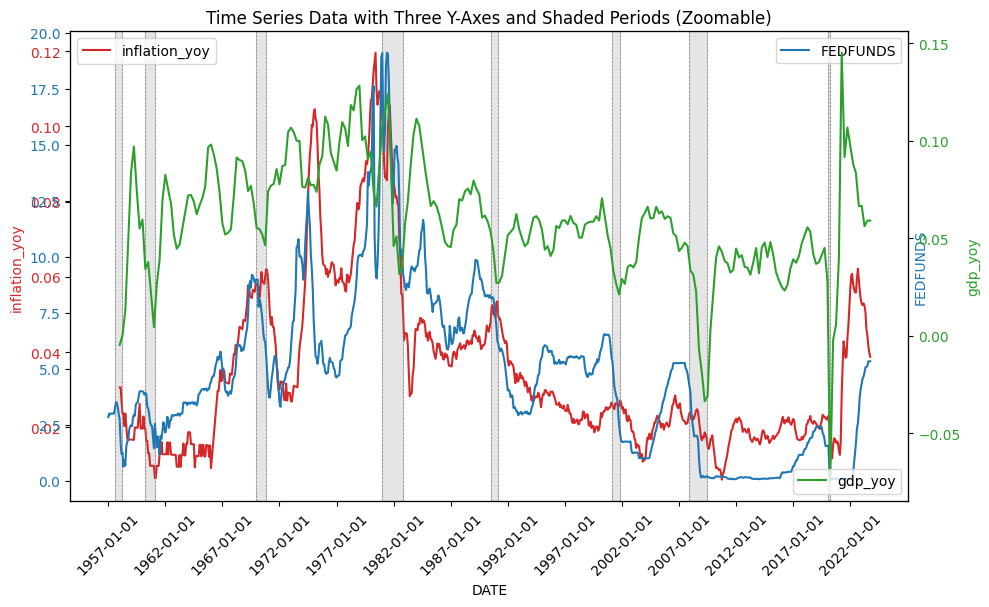

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'merged_df' is your DataFrame
# Convert 'DATE' column to datetime type (if not already)
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first variable on the left y-axis
color1 = 'tab:red'
ax1.set_xlabel('DATE')
ax1.set_ylabel('inflation_yoy', color=color1)
line1, = ax1.plot(merged_df['DATE'], merged_df['inflation_yoy'], color=color1, label='inflation_yoy')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis (right y-axis) for the second variable
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('FEDFUNDS', color=color2)
line2, = ax2.plot(merged_df['DATE'], merged_df['FEDFUNDS'], color=color2, label='FEDFUNDS')
ax2.tick_params(axis='y', labelcolor=color2)

# Plot the third variable on the same scale as the second variable
ax3 = ax2.twinx()
color3 = 'tab:green'
ax3.set_ylabel('gdp_yoy', color=color3)
line3, = ax3.plot(merged_df['DATE'], merged_df['gdp_yoy'], color=color3, label='gdp_yoy')
ax3.tick_params(axis='y', labelcolor=color3)

# Add vertical lines and color areas between lines
# Define the periods you want to grey out (adjust these dates based on your data)
periods = [
    ('1957-08-01', '1958-04-01'),
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01','1970-11-01'),
    ('1981-01-01','1982-11-01'),
    ('1990-07-01','1991-03-01'),
    ('2001-03-01','2001-11-01'),
    ('2007-12-01','2009-06-01'),
    ('2020-02-01','2020-04-01')
]

for start, end in periods:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    # Add vertical lines
    ax1.axvline(x=start, color='grey', linestyle='--', linewidth=0.5)
    ax1.axvline(x=end, color='grey', linestyle='--', linewidth=0.5)

    # Add colored areas between lines
    ax1.axvspan(start, end, alpha=0.2, color='grey')

# Set x-axis ticks and labels
n = 60  # Display every 60th label
ax1.set_xticks(merged_df['DATE'][::n])
ax1.set_xticklabels(merged_df['DATE'].dt.strftime('%Y-%m-%d')[::n], rotation=45)

# Display the legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='lower right')

# Add cursor to display values when hovering over the plot
axcursor = fig.canvas.mpl_connect('motion_notify_event', lambda event: on_move(event, ax1, ax2, ax3))

# Zooming variables
zoom_start = None

def on_move(event, ax1, ax2, ax3):
    global zoom_start
    
    if zoom_start is not None:
        xlim = sorted([zoom_start, event.xdata])
        ax1.set_xlim(xlim)
        ax2.set_xlim(xlim)
        ax3.set_xlim(xlim)
        fig.canvas.draw()

# On key press, start or end zoom
def on_click(event):
    global zoom_start
    
    if event.key == 'shift':
        if zoom_start is None:
            zoom_start = event.xdata
        else:
            zoom_start = None

# Attach the events
fig.canvas.mpl_connect('key_press_event', on_click)

# Adjust the layout to prevent overlapping labels
fig.tight_layout()

plt.title('Time Series Data with Three Y-Axes and Shaded Periods (Zoomable)')
plt.show()


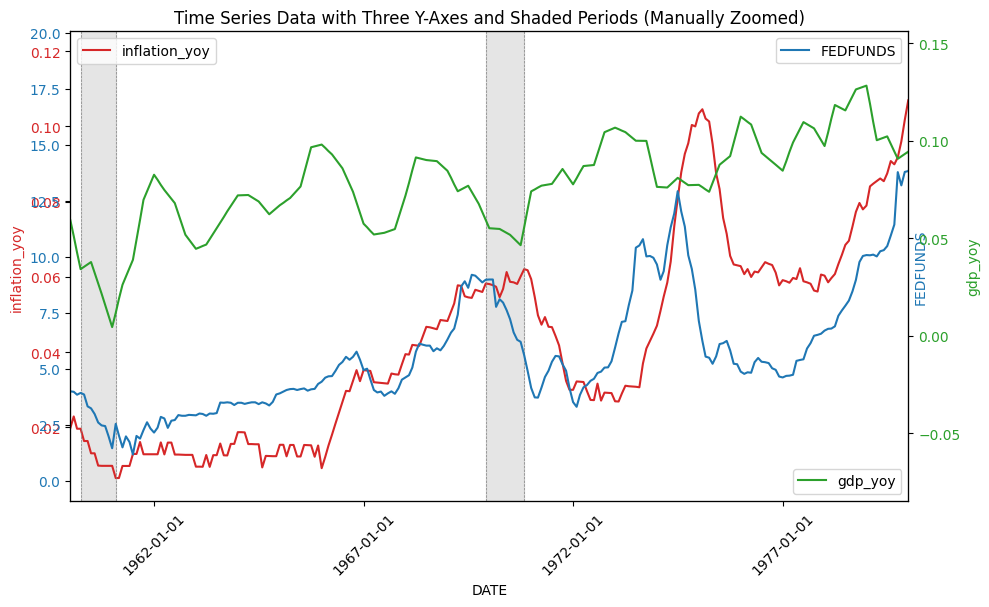

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'merged_df' is your DataFrame
# Convert 'DATE' column to datetime type (if not already)
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first variable on the left y-axis
color1 = 'tab:red'
ax1.set_xlabel('DATE')
ax1.set_ylabel('inflation_yoy', color=color1)
line1, = ax1.plot(merged_df['DATE'], merged_df['inflation_yoy'], color=color1, label='inflation_yoy')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis (right y-axis) for the second variable
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('FEDFUNDS', color=color2)
line2, = ax2.plot(merged_df['DATE'], merged_df['FEDFUNDS'], color=color2, label='FEDFUNDS')
ax2.tick_params(axis='y', labelcolor=color2)

# Plot the third variable on the same scale as the second variable
ax3 = ax2.twinx()
color3 = 'tab:green'
ax3.set_ylabel('gdp_yoy', color=color3)
line3, = ax3.plot(merged_df['DATE'], merged_df['gdp_yoy'], color=color3, label='gdp_yoy')
ax3.tick_params(axis='y', labelcolor=color3)

# Add vertical lines and color areas between lines
# Define the periods you want to grey out (adjust these dates based on your data)
periods = [
    ('1957-08-01', '1958-04-01'),
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01','1970-11-01'),
    ('1981-01-01','1982-11-01'),
    ('1990-07-01','1991-03-01'),
    ('2001-03-01','2001-11-01'),
    ('2007-12-01','2009-06-01'),
    ('2020-02-01','2020-04-01')
]

for start, end in periods:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    # Add vertical lines
    ax1.axvline(x=start, color='grey', linestyle='--', linewidth=0.5)
    ax1.axvline(x=end, color='grey', linestyle='--', linewidth=0.5)

    # Add colored areas between lines
    ax1.axvspan(start, end, alpha=0.2, color='grey')

# Set x-axis ticks and labels
n = 60  # Display every 60th label
ax1.set_xticks(merged_df['DATE'][::n])
ax1.set_xticklabels(merged_df['DATE'].dt.strftime('%Y-%m-%d')[::n], rotation=45)

# Display the legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='lower right')

# Manually set the x-axis limits for zooming (adjust these values accordingly)
ax1.set_xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('1980-01-01'))

# Adjust the layout to prevent overlapping labels
fig.tight_layout()

plt.title('Time Series Data with Three Y-Axes and Shaded Periods (Manually Zoomed)')
plt.show()
